In [2]:
# 确保从本仓库根目录导入 syng_bts（优先于已安装的同名包）
import sys
from pathlib import Path

def _find_repo_root():
    """从当前目录或父目录中找到包含 syng_bts 的仓库根目录。"""
    start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "syng_bts").is_dir() and (p / "syng_bts" / "experiments.py").exists():
            return p
    return start  # fallback

_repo_root = _find_repo_root()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
print(f"Using local syng_bts from: {_repo_root}")

Using local syng_bts from: /Users/yanjiechen/Documents/Github/SyNG-BTS_2.6


In [3]:
# 依赖上一格将仓库根加入 sys.path，此处导入本地 syng_bts
from syng_bts.experiments import *

/Users/yanjiechen/Documents/Github/SyNG-BTS/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Read data: SKCMPositive_4
2. Determine the model is VAE1-10 with recon:kl = 1:10
3. Determine the training parameters are epoch = early_stop off_aug = No learing rate = 0.0005 batch_frac = 0.1
4. Pilot experiments start ... 
Training for data=SKCMPositive_4, model=epochES_batch01_VAE1-10, pilot size=100, for 1-th draw

 Epoch 1/1000 - Learning Rate: 0.000500
Epoch: 001/1000 | Batch 0000/0008 | Loss: 27208.9355
Epoch: 001/1000 | Batch 0001/0008 | Loss: 27191.8340
Epoch: 001/1000 | Batch 0002/0008 | Loss: 27172.6953
Epoch: 001/1000 | Batch 0003/0008 | Loss: 27152.3867
Epoch: 001/1000 | Batch 0004/0008 | Loss: 27127.4473
Epoch: 001/1000 | Batch 0005/0008 | Loss: 27092.5879
Epoch: 001/1000 | Batch 0006/0008 | Loss: 27047.6797
Epoch: 001/1000 | Batch 0007/0008 | Loss: 26982.7168
Time elapsed: 0.00 min

 Epoch 2/1000 - Learning Rate: 0.000500
Epoch: 002/1000 | Batch 0000/0008 | Loss: 26887.4727
Epoch: 002/1000 | Batch 0001/0008 | Loss: 26751.6660
Epoch: 002/1000 | Batch 0002/0008 | Loss: 

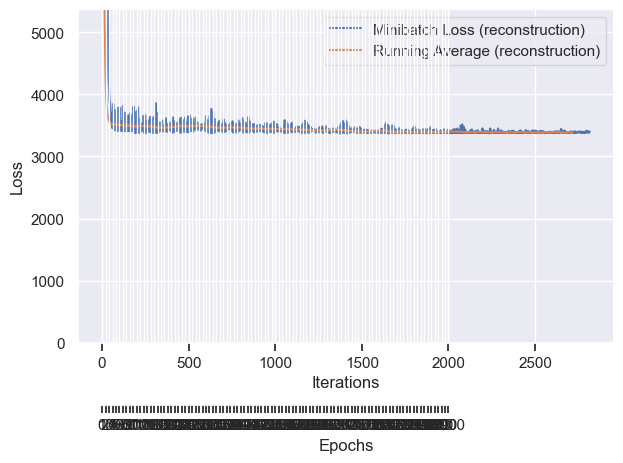

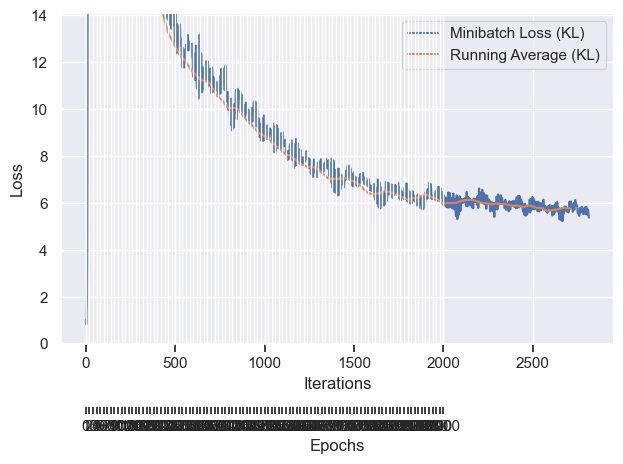

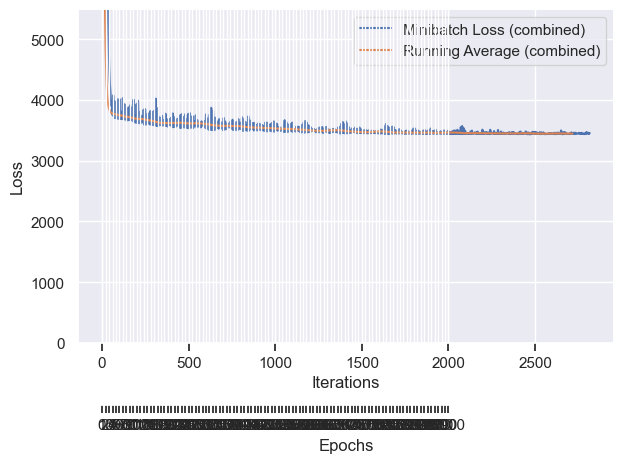

KeyboardInterrupt: 

In [4]:
#%% run pilot experiments
# This function trains VAE or CVAE, or GAN, WGAN, WGANGP, MAF, GLOW, RealNVP 
#      with several pilot size given data, model, batch_size, learning_rate, epoch, off_aug and pre_model
#      for each pilot size, there will be 5 draws, 
#      for each draw, the data is augmented to 5 times the original sample size.
# dataname :         pure data name without .csv. Eg: SKCMPositive_3
# pilot_size:        a set including potential pilot sizes
# model:             name of the model to be trained
# batch_frac:        batch fraction
# learning_rate:     learning rate 
# epoch:             choose from None (early_stop), or any interger, if choose None, early_stop_num will take effect
# early_stop_num:    if loss does not improve for early_stop_num epochs, the training will stop. Default value is 30. Only take effect when epoch == "early_stop"
# off_aug:           choose from AE_head, Gaussian_head, None. if choose AE_head, AE_head_num will take effect. If choose Gaussian_head, Gaussian_head_num will take effect. If choose None, no offline augmentation
# AE_head_num:       how many folds of AEhead augmentation needed. Default value is 2, Only take effect when off_aug == "AE_head"
# Gaussian_head_num: how many folds of Gaussianhead augmentation needed. Default value is 9, Only take effect when off_aug == "Gaussian_head"
# pre_model:         transfer learning input model. If pre_model == None, no transfer learning

PilotExperiment(dataname = "SKCMPositive_4", pilot_size = [100],
                model = "VAE1-10", batch_frac = 0.1, 
                learning_rate = 0.0005, pre_model = None,
                epoch = None,  off_aug = None, early_stop_num = 30,
                AE_head_num = 2, Gaussian_head_num = 9)

In [ ]:
#%% running application on case study BRCASubtype
# This function trains VAE or CVAE, or GAN, WGAN, WGANGP, MAF, GLOW, RealNVP 
#      given data, model, batch_size, learning_rate, epoch, off_aug and pre_model
#      and generate new samples with size specified by the users.
# path:              path for reading real data and saving new data
# dataname :         pure data name without .csv. Eg: SKCMPositive_3
# apply_log:         logical whether apply log transformation before training
# model:             name of the model to be trained
# batch_frac:        batch fraction
# learning_rate:     learning rate 
# epoch:             choose from None (early_stop), or any interger, if choose None, early_stop_num will take effect
# early_stop_num:    if loss does not improve for early_stop_num epochs, the training will stop. Default value is 30. Only take effect when epoch == "early_stop"
# off_aug:           choose from AE_head, Gaussian_head, None. if choose AE_head, AE_head_num will take effect. If choose Gaussian_head, Gaussian_head_num will take effect. If choose None, no offline augmentation
# AE_head_num:       how many folds of AEhead augmentation needed. Default value is 2, Only take effect when off_aug == "AE_head"
# Gaussian_head_num: how many folds of Gaussianhead augmentation needed. Default value is 9, Only take effect when off_aug == "Gaussian_head"
# pre_model:         transfer learning input model. If pre_model == None, no transfer learning
# save_model:        if the trained model should be saved, specify the path and name of the saved model
        
ApplyExperiment(path = "/Users/yanjiechen/Documents/Github/SyNG-BTS_2.6/syng_bts/data/case/lihc_subtype/",
                dataname = "LIHCSubtypeFamInd_train294_DESeq",
                apply_log = True, 
                new_size = [1000],
                model = "CVAE1-10",
                batch_frac = 0.1,
                learning_rate = 0.00015,
                epoch = 10000,
                early_stop_num = 200, 
                data_type = "miRNA",
                off_aug = None, AE_head_num = 2, Gaussian_head_num = 9, pre_model = None, save_model = None)

1. Read data: LIHCSubtypeFamInd_train294_DESeq
2. Determine the model is CVAE1-10 with recon:kl = 1:10
3. Determine the training parameters are epoch = early_stop off_aug = No learing rate = 0.0002 batch_frac = 0.1
4. Data type: miRNA ; Encoder dimensions: (256, 128, 64)
5. Training starts ......

 Epoch 1/10000 - Learning Rate: 0.000200
Epoch: 001/10000 | Batch 0000/0008 | Loss: 24798.2793
Epoch: 001/10000 | Batch 0001/0008 | Loss: 24794.1680
Epoch: 001/10000 | Batch 0002/0008 | Loss: 24783.5391
Epoch: 001/10000 | Batch 0003/0008 | Loss: 24766.2383
Epoch: 001/10000 | Batch 0004/0008 | Loss: 24743.5430
Epoch: 001/10000 | Batch 0005/0008 | Loss: 24717.3652
Epoch: 001/10000 | Batch 0006/0008 | Loss: 24688.4922
Epoch: 001/10000 | Batch 0007/0008 | Loss: 24657.7793
Time elapsed: 0.00 min

 Epoch 2/10000 - Learning Rate: 0.000200
Epoch: 002/10000 | Batch 0000/0008 | Loss: 24624.3594
Epoch: 002/10000 | Batch 0001/0008 | Loss: 24585.7891
Epoch: 002/10000 | Batch 0002/0008 | Loss: 24542.3555
E

KeyboardInterrupt: 

In [ ]:
#%% Running transfer learning
# This function run transfer learning using VAE or CVAE, or GAN, WGAN, WGANGP, MAF, GLOW, RealNVP 
#      given fromdata, todata, model, batch_size, learning_rate, epoch, off_aug and pre_model
#      and generate new samples with size specified by the users.
#      The fine tuning model training can be pilot experiments or apply experiment
# Make sure data files for pre_model training and fine tuning model training are in Transfer/
# pilot_size:        if None, the fine tuning model will be apply experiment and new_size will take effect
#                    otherwise, the fine tuning model will be trained using pilot experiments
# fromname:          the dataname for pre_model training 
# toname:            the dataname for fine tuning model training
# fromsize:          the sample size of the fromdata
# new_size:          if apply experiment, this will be the sample size of generated samples
# apply_log:         logical whether apply log transformation before training
# model:             name of the model to be trained
# batch_frac:        batch fraction
# learning_rate:     learning rate 
# epoch:             choose from None (early_stop), or any interger, if choose None, early_stop_num will take effect
# off_aug:           choose from AE_head, Gaussian_head, None. if choose AE_head, AE_head_num will take effect. If choose Gaussian_head, Gaussian_head_num will take effect. If choose None, no offline augmentation
TransferExperiment(pilot_size = None, fromname = "PRAD", toname = "BRCA", fromsize = 551, 
         new_size = 500, apply_log = True, model = "maf", epoch = 10,
         batch_frac = 0.1, learning_rate = 0.0005, off_aug = None)